In [1]:
# run the following when using CPU
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = "-1"  # hide GPUs 

In [2]:
# Ensure local pymdp submodule is importable when running from repo root


In [3]:
import jax.numpy as jnp
import jax.tree_util as jtu
from jax import random as jr, config, jit
from jax import nn
from pymdp.agent import Agent as AIFAgent

# config.update("jax_default_matmul_precision", "float32")
# config.update("jax_default_matmul_precision", "tensorfloat32")
# config.update("jax_default_matmul_precision", "bfloat16")

# config.update('jax_platform_name', 'cpu') # run this when using CPU

In [4]:
import os

# disable preallocation
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

# or change the preallocation fraction (e.g., 50%)
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.75'

In [5]:
import os
os.environ['XLA_FLAGS'] = (
    '--xla_gpu_triton_gemm_any=True '
    '--xla_gpu_enable_latency_hiding_scheduler=true '
)

In [6]:
# how to explicitly specify CPU cores when running on CPU

# import os
# import jax

# # get the number of CPU cores on this machine
# cpu_count = os.cpu_count()
# os.environ["XLA_FLAGS"] = f"--xla_cpu_multi_thread_eigen=true intra_op_parallelism_threads={cpu_count}"

# from jax import config
# config.update('jax_platform_name', 'cpu')  # run on CPU

# print(f"CPU core count: {cpu_count}")

In [7]:
# check the jax version
import jax
jax.__version__

'0.9.0'

In [8]:
!nvidia-smi 

zsh:1: command not found: nvidia-smi


In [9]:
# from jax.lib import xla_bridge
# print(xla_bridge.get_backend().platform)

print(jax.extend.backend.get_backend().platform)

cpu


In [10]:
print(jax.devices())  # [CudaDevice(id=0)] means GPU、[CpuDevice(id=0)] means CPU

[CpuDevice(id=0)]


In [11]:
import gymnax


In [12]:
from functools import partial
from typing import NamedTuple

from jax import jit, lax, nn
import jax.numpy as jnp
import jax.tree_util as jtu
from gymnax.environments.classic_control.cartpole import EnvState as GymnaxEnvState
from pymdp.envs.env import Env


class GymnaxCartPoleState(NamedTuple):
    x: jnp.ndarray
    x_dot: jnp.ndarray
    theta: jnp.ndarray
    theta_dot: jnp.ndarray
    time: jnp.ndarray
    done: jnp.ndarray


class GymnaxCartPoleEnv(Env):

    def __init__(self, num_obs, action_division=2):
        self.num_obs = num_obs
        self.num_actions = action_division
        self.env, self._default_env_params = gymnax.make("CartPole-v1")

        # ranges for discretization (match old notebook)
        self.cart_position_max = 4.8 / 2 * 2
        self.cart_velocity_max = 2.5 * 2
        self.pole_angle_max = 0.418 / 2 * 2
        self.pole_ang_velocity_max = 3.0 * 2

        # goal position (index)
        self.goal_pole_angle = 0
        self.goal_pole_angle = (self.goal_pole_angle + self.pole_angle_max) / (2 * self.pole_angle_max / (self.num_obs[1] - 1))
        print(f'index of goal_pole_angle = {self.goal_pole_angle}')

    def generate_env_params(self, key=None, batch_size=None):
        params = self._default_env_params
        if batch_size is None:
            return params

        def _expand(x):
            x = jnp.asarray(x)
            return jnp.broadcast_to(x, (batch_size,) + x.shape)

        return jtu.tree_map(_expand, params)

    def _discretize(self, x, x_max, n_bins):
        bin_size = (2 * x_max) / (n_bins - 1)
        idx = jnp.rint((x + x_max) / bin_size)
        idx = jnp.clip(idx, 0, n_bins - 1)
        return idx.astype(jnp.int32)

    def _obs_to_onehot(self, obs, action):
        cart_velocity = self._discretize(obs[1], self.cart_velocity_max, self.num_obs[0])
        pole_angle = self._discretize(obs[2], self.pole_angle_max, self.num_obs[1])
        pole_ang_velocity = self._discretize(obs[3], self.pole_ang_velocity_max, self.num_obs[2])
        action = action.astype(jnp.int32)
        observation = [
            nn.one_hot(cart_velocity, self.num_obs[0])[None, :],
            nn.one_hot(pole_angle, self.num_obs[1])[None, :],
            nn.one_hot(pole_ang_velocity, self.num_obs[2])[None, :],
            nn.one_hot(action, self.num_obs[3])[None, :],
        ]
        return observation

    def _pack_state(self, state, done):
        return GymnaxCartPoleState(
            x=state.x,
            x_dot=state.x_dot,
            theta=state.theta,
            theta_dot=state.theta_dot,
            time=state.time,
            done=done,
        )

    def _unpack_state(self, state):
        return GymnaxEnvState(
            x=state.x,
            x_dot=state.x_dot,
            theta=state.theta,
            theta_dot=state.theta_dot,
            time=state.time,
        )

    @partial(jit, static_argnums=(0,))
    def reset(self, key, state=None, env_params=None):
        if env_params is None:
            env_params = self._default_env_params
        obs, raw_state = self.env.reset(key, env_params)
        action_obs = jnp.array(0, dtype=jnp.int32)
        observation = self._obs_to_onehot(obs, action_obs)
        wrapped_state = self._pack_state(raw_state, jnp.array(False))
        return observation, wrapped_state

    @partial(jit, static_argnums=(0,))
    def step(self, key, state, action, env_params=None):
        if env_params is None:
            env_params = self._default_env_params

        action = jnp.ravel(action)[0].astype(jnp.int32)
        raw_state = self._unpack_state(state)

        # Use step_env to avoid Gymnax auto-reset and preserve episode boundaries.
        obs_prev = self.env.get_obs(raw_state)
        obs_next, raw_state_next, _, done_next, _ = self.env.step_env(key, raw_state, action, env_params)

        raw_state_out = jtu.tree_map(
            lambda new, old: lax.select(state.done, old, new),
            raw_state_next,
            raw_state,
        )
        obs_out = lax.select(state.done, obs_prev, obs_next)
        done_out = jnp.logical_or(state.done, done_next)

        wrapped_state_out = self._pack_state(raw_state_out, done_out)
        observation = self._obs_to_onehot(obs_out, action)
        return observation, wrapped_state_out


## **Imports some helpful libraries, most importantly `numpy` and `pymdp`**

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from pymdp.legacy import utils

### Let's set up the dimensionalities of the hidden state factors and the control states

In [14]:
""" Define dimensionalities of the hidden state factors and control state factors """

obs_division = 64
action_division = 2

num_obs = [obs_division, obs_division, obs_division, action_division]
num_modalities = len(num_obs)
print(f'num_obs : {num_obs}')
print(f'num_modalities : {num_modalities}')

num_controls = [action_division] # a list of the dimensionalities of each control state factor
num_control_factors = len(num_controls) # the total number of control state factors
print(f'num_controls : {num_controls}')
print(f'num_control_factors : {num_control_factors}')

# num_states = [(num_modalities-num_control_factors)*max(2,int(np.ceil(np.log2(obs_division)))) + num_control_factors*max(2,int(np.ceil(np.log2(action_division))))]
num_states = [(num_modalities+1)*2]
print(f'num_states : {num_states}')
num_factors = len(num_states) # the total number of hidden state factors

num_obs : [64, 64, 64, 2]
num_modalities : 4
num_controls : [2]
num_control_factors : 1
num_states : [10]


A is normalized : True
A[0].shape : (64, 10)
A[1].shape : (64, 10)
A[2].shape : (64, 10)
A[3].shape : (2, 10)
A[0]


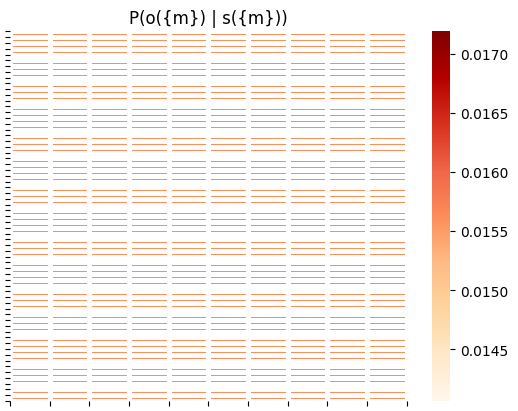

A[1]


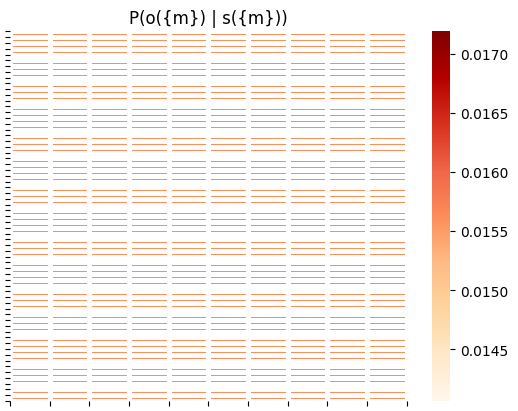

A[2]


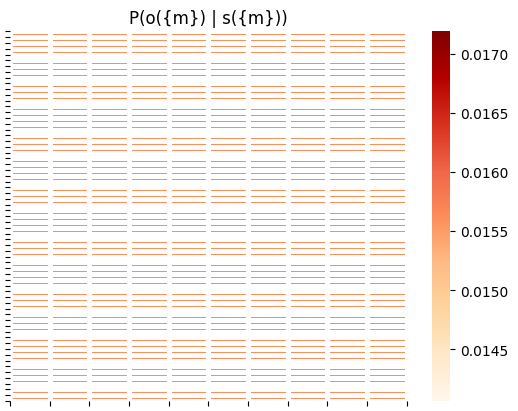

A[3]


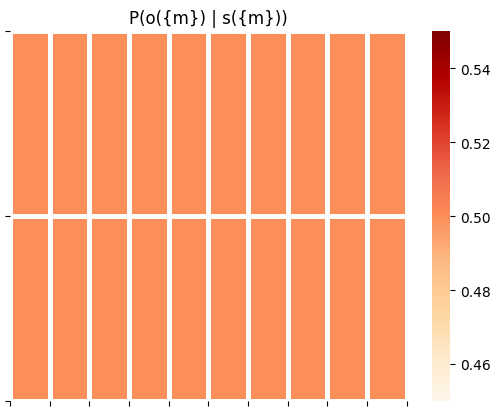

In [15]:
""" Build an object array for A matrices """

#A_m_shapes = [ [o_dim] + num_states for o_dim in num_obs] # list of shapes of modality-specific A[m] arrays
#A = utils.obj_array_zeros(A_m_shapes) # initialize A array to an object array of all-zero subarrays

#A = utils.initialize_empty_A(num_obs, num_states)

A = utils.random_A_matrix(num_obs, num_states)
A = A*0 + 1

# Sum of columns must be one
A = utils.norm_dist_obj_arr(A)

print(f'A is normalized : {utils.is_normalized(A)}')

for m in range(len(A)):
    print(f'A[{m}].shape : {A[m].shape}')

for m in range(len(A)):
    print(f'A[{m}]')
    utils.plot_likelihood(A[m][:,:], title = "P(o({m}) | s({m}))" )

B is normalized : True
B[0].shape : (10, 10, 2)
B[0]
action = 0


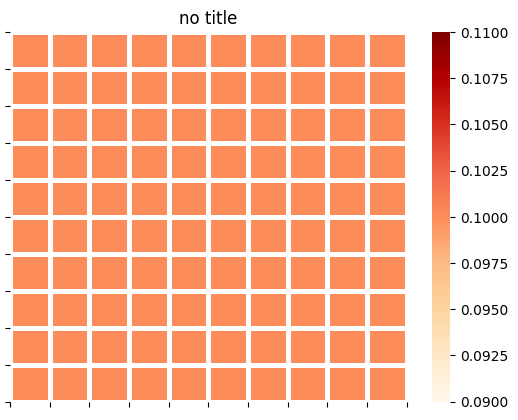

B[0]
action = 1


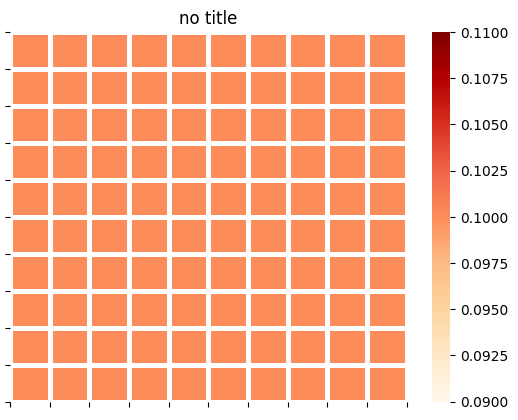

In [16]:
""" Build an object array for storing the factor-specific B matrices """

# initialize the shapes of each sub-array `B[f]`
#B_f_shapes = [ [ns, ns, num_controls[f]] for f, ns in enumerate(num_states)]

# create the `B` array and fill it out
#B = utils.obj_array_zeros(B_f_shapes)

#B = utils.initialize_empty_B(num_states, num_controls)

B = utils.random_B_matrix(num_states, num_controls)

# Uniform B
B = B*0 + 1
# Sum of columns must be one
B = utils.norm_dist_obj_arr(B)

print(f'B is normalized : {utils.is_normalized(B)}')

for f in range(len(B)):
    print(f'B[{f}].shape : {B[f].shape}')

for f,actions in enumerate(num_controls):
    for a in range(actions):
        print(f'B[{f}]')
        print(f'action = {a}')
        utils.plot_likelihood(B[f][:,:,a], title = 'no title')

In [17]:
env = GymnaxCartPoleEnv(num_obs)


index of goal_pole_angle = 31.499999999999996


In [18]:
# gymnax has no viewer to close


log(softmax(C[0])) finite: True


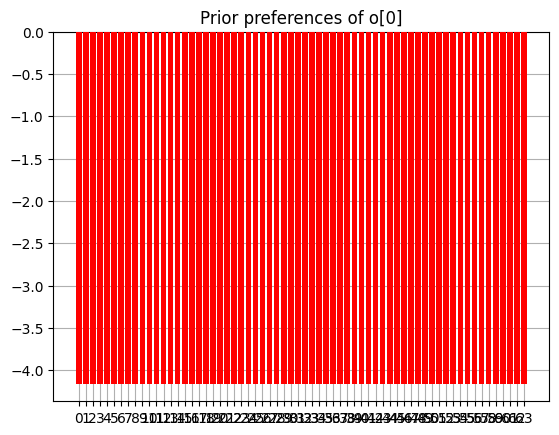

log(softmax(C[1])) finite: True


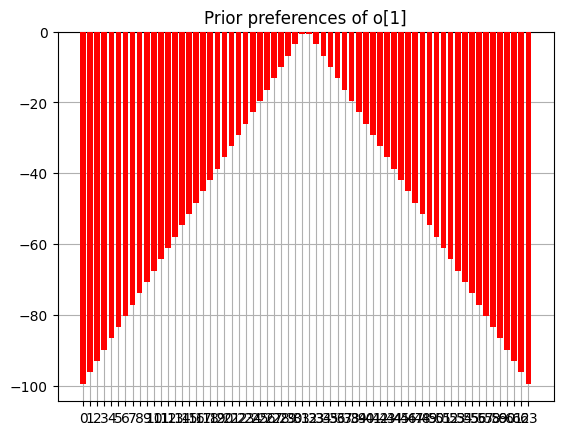

log(softmax(C[2])) finite: True


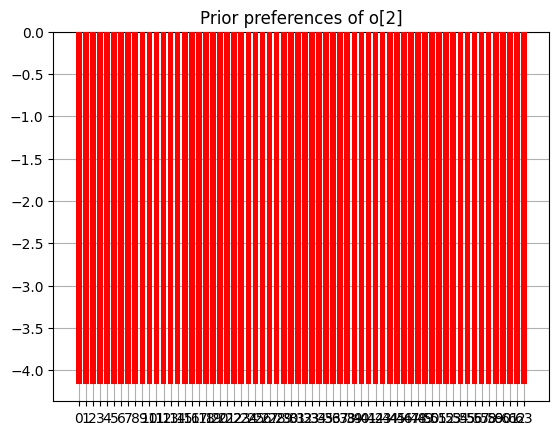

log(softmax(C[3])) finite: True


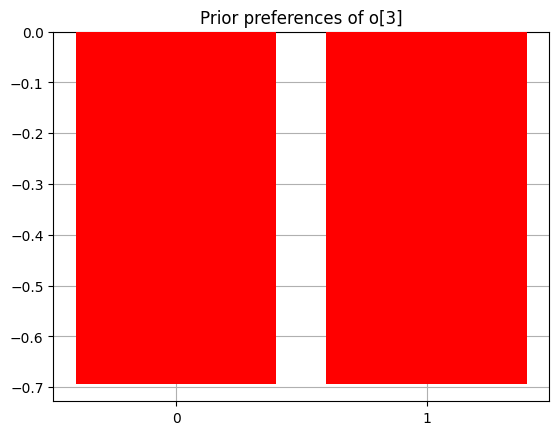

In [19]:
goal_pole_angle = env.goal_pole_angle # index @ pole angle = 0[deg]

def create_C(sigma=1.0):

    C = utils.obj_array_zeros(num_obs)

    x = np.linspace(0, obs_division - 1, obs_division, dtype=np.float64)

    # Logistic preference profile around upright pole angle.
    mu = goal_pole_angle
    s = sigma * 0.5513 * 0.25
    z = (x - mu) / s

    # Stable log-pdf: log(sigmoid'(z) / s) = -z - log(s) - 2*log(1 + exp(-z)).
    C[1] = -z - np.log(s) - 2.0 * np.logaddexp(0.0, -z)

    return C

C = create_C(sigma=1.7 / (env.pole_angle_max * 180 / 3.14159) * (num_obs[1] / 2)) # sigma=1.7deg

# Convert each modality preference to normalized log probabilities.
for m in range(len(C)):
    C[m] = np.asarray(nn.log_softmax(jnp.asarray(C[m], dtype=jnp.float32)))

for m in range(len(C)):
    print(f'log(softmax(C[{m}])) finite: {np.isfinite(C[m]).all()}')
    utils.plot_beliefs(C[m], title = f"Prior preferences of o[{m}]")


x : [-4.5 -3.5 -2.5 -1.5 -0.5  0.5  1.5  2.5  3.5  4.5]
D[0] : [0.00359724 0.00853025 0.01955452 0.04172171 0.0781365  0.12186352
 0.1582783  0.18044548 0.19146976 0.19640276]
D[0]


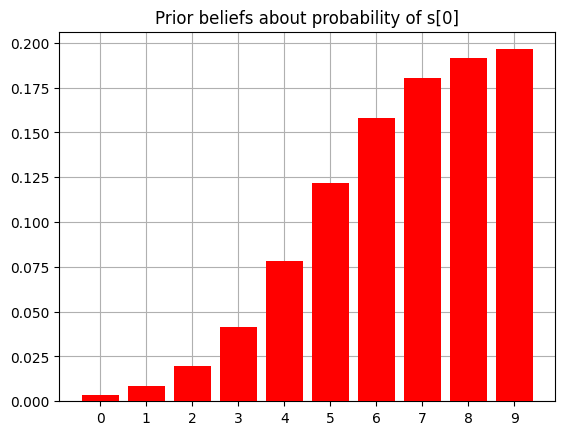

In [20]:
#D[0] = np.ones(num_states[0]) / (num_states[0])
D = utils.obj_array_uniform(num_states)

#D[0] = utils.onehot(0, num_states)

#D = utils.random_single_categorical(num_states)

##D[0] = softmax(np.log(np.linspace(1e-16, num_states[0]-1, num_states[0])))
#D[0] = softmax(np.log(np.linspace(1, num_states[0], num_states[0])))

a = 4.0 / ((int(num_states[0])-1)/2)
x = np.linspace(0, int(num_states[0])-1, int(num_states[0])) - (int(num_states[0])-1)/2
print(f'x : {x}')
D[0] = nn.softmax(np.log(1/(1+np.exp(-a*x))))

for f in range(len(D)):
    print(f'D[{f}] : {D[f]}')
    print(f'D[{f}]')
    utils.plot_beliefs(D[f], title = f"Prior beliefs about probability of s[{f}]")

In [21]:
total_combinations = np.prod(num_obs)
print(f'Total number of observation combinations: {total_combinations}')

total_elements_A = sum(a.size for a in A)
print(f'Total number of elements in A tensor: {total_elements_A}')

total_elements_B = sum(b.size for b in B)
print(f'Total number of elements in B tensor: {total_elements_B}')

観測値の組み合わせ総数: 524288
Aテンソルの要素数の合計: 1940
Bテンソルの要素数の合計: 200


In [22]:
pA = utils.dirichlet_like(A, scale = 1e-2)
pB = utils.dirichlet_like(B, scale = 1e-2)

# Convert each element of pA and pB to float32 JAX arrays
pA = [jnp.array(item, dtype=jnp.float32) for item in pA]
pB = [jnp.array(item, dtype=jnp.float32) for item in pB]

## Now let's take advantage of the `Agent` class in `pymdp` to wrap this all into an Agent instance that we can use to do active inference in a few lines.

In [23]:
from equinox import tree_at
from jax import jit
from pymdp.envs.rollout import rollout

batch_size = 1
policy_length = 2
inference_horizon = 8
max_steps_per_episode = 500
num_episodes = 400
learn_D = True

A_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(A))
B_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(B))
C_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(C))
D_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(D))

pA_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(pA))
pB_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(pB))

# rollout() expects env params batched across the first dimension
env_params = env.generate_env_params(batch_size=batch_size)

agents = AIFAgent(
    A=A_jax,
    B=B_jax,
    C=C_jax,
    D=D_jax,
    E=None,
    pA=pA_jax,
    pB=pB_jax,
    learn_A=True,
    learn_B=True,
    learn_C=False,
    learn_D=learn_D,
    learn_E=False,
    A_dependencies=None,
    B_dependencies=None,
    gamma=1.0,
    alpha=1.0,
    inference_algo="mmp",
    inference_horizon=inference_horizon,
    action_selection="stochastic",
    policy_len=policy_length,
    use_utility=True,
    use_states_info_gain=True,
    use_param_info_gain=True,
    use_inductive=False,
    categorical_obs=True,
    sampling_mode="full",
    num_iter=max(16, inference_horizon),
    batch_size=batch_size,
    learning_mode="offline",
)

jit_rollout = jit(rollout, static_argnums=(1, 2))


def _trim_outcomes(obs_tree):
    def _trim(x):
        if x.ndim >= 3 and x.shape[2] == 1:
            x = jnp.squeeze(x, axis=2)
        return x

    return jtu.tree_map(_trim, obs_tree)


def _concat_tree(chunks):
    if len(chunks) == 1:
        return chunks[0]
    return jtu.tree_map(lambda *xs: jnp.concatenate(xs, axis=1), *chunks)


def _steps_until_done(info_block, last_block):
    done_pre = np.asarray(info_block["env_state"].done[0], dtype=bool)
    done_last = bool(np.asarray(last_block["env_state"].done[0]))
    done_next = np.concatenate([done_pre[1:], np.asarray([done_last], dtype=bool)])
    if done_next.any():
        return int(np.argmax(done_next)) + 1, True
    return int(done_next.shape[0]), False


master_key = jr.PRNGKey(0)

T_episode_maxes = []
efe_means = []
vfe_means = []

pD = [jnp.zeros_like(d) for d in agents.D]
qs_t0 = [jnp.zeros_like(d) for d in agents.D]

last = None
info = None
outcomes = None
actions = None
infer_args = (agents.D, None)

for episode in range(num_episodes):
    print(f'episode : {episode}')

    if episode > 0:
        pD = [pd + q0 for pd, q0 in zip(pD, qs_t0)]
        D_learned = [pd / (jnp.sum(pd, axis=1, keepdims=True) + 1e-16) for pd in pD]
        if learn_D:
            agents = tree_at(lambda x: x.D, agents, D_learned)
        else:
            agents = tree_at(lambda x: x.D, agents, D_jax)

    block_carry = None
    step_count = 0
    done = False
    first_block = True

    efe_chunks = []
    outcome_chunks = []
    action_chunks = []
    qs_chunks = []

    while (not done) and (step_count < max_steps_per_episode):
        block_steps = min(inference_horizon, max_steps_per_episode - step_count)

        master_key, block_key = jr.split(master_key)
        last_block, info_block = jit_rollout(
            agents,
            env,
            block_steps - 1,
            block_key,
            initial_carry=block_carry,
            env_params=env_params,
        )

        agents = last_block["agent"]
        valid_steps, done = _steps_until_done(info_block, last_block)
        history_start = max(inference_horizon - valid_steps, 0)

        obs_block = _trim_outcomes(info_block["observation"])
        obs_block = jtu.tree_map(lambda x: x[:, :valid_steps], obs_block)
        action_block = info_block["action"][:, :valid_steps, :]
        qs_block = jtu.tree_map(lambda x: x[:, :valid_steps, :], info_block["qs"])
        G_block = np.asarray(info_block["G"][0, :valid_steps])

        outcome_chunks.append(obs_block)
        action_chunks.append(action_block)
        qs_chunks.append(qs_block)
        efe_chunks.append(-G_block)

        if first_block:
            # For short episodes (< inference_horizon), beliefs are right-aligned in the history window.
            qs_t0 = jtu.tree_map(lambda x: x[:, history_start], last_block["qs"])
            first_block = False

        # Mirror the original notebook's finite-horizon D update.
        agents = tree_at(lambda x: x.D, agents, jtu.tree_map(lambda x: x[:, history_start], last_block["qs"]))

        step_count += valid_steps

        if done:
            last = last_block
            info = info_block
            break

        block_carry = dict(last_block)
        block_carry["agent"] = agents

        last = last_block
        info = info_block

    T_episode_maxes.append(step_count)

    if efe_chunks:
        efe_episode = np.concatenate(efe_chunks, axis=0)
        efe_mean = np.mean(efe_episode, axis=0)
    else:
        efe_mean = np.array(0.0)
    efe_means.append(efe_mean)
    vfe_means.append(np.array(0.0))

    print(f'efe_mean in episode {episode}: {efe_mean}')

    if outcome_chunks:
        outcomes = _concat_tree(outcome_chunks)
        actions = jnp.concatenate(action_chunks, axis=1)
        qs_hist = _concat_tree(qs_chunks)
        infer_args = (agents.D, qs_hist)

onehot_obs = True
vfes = None


/var/folders/_f/1qqqnkyd5k5g2b1pgfwzzrqm0000gn/T/ipykernel_87619/4039163932.py:23: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  agents = AIFAgent(


episode : 0
efe_mean in episode 0: [37.911312 38.108593 38.11901  38.321156]
episode : 1
efe_mean in episode 1: [43.327084 43.424038 43.434505 43.534573]
episode : 2
efe_mean in episode 2: [50.095715 49.743824 49.728382 49.40737 ]
episode : 3
efe_mean in episode 3: [47.270157 46.932674 46.87417  46.599438]
episode : 4
efe_mean in episode 4: [52.197174 50.972385 50.87227  49.69856 ]
episode : 5
efe_mean in episode 5: [52.154015 51.53236  51.52221  51.008476]
episode : 6
efe_mean in episode 6: [52.666035 52.67753  52.63617  52.77088 ]
episode : 7
efe_mean in episode 7: [54.82684  53.94667  53.958393 53.25945 ]
episode : 8
efe_mean in episode 8: [55.495354 55.398563 55.58838  55.76807 ]
episode : 9
efe_mean in episode 9: [56.81815 56.51886 56.64435 56.50829]
episode : 10
efe_mean in episode 10: [56.2335   56.486343 56.390488 56.91667 ]
episode : 11
efe_mean in episode 11: [56.024853 56.108864 56.413742 56.909706]
episode : 12
efe_mean in episode 12: [56.54556  57.505344 57.47569  58.88266

In [24]:
# gymnax has no viewer to close


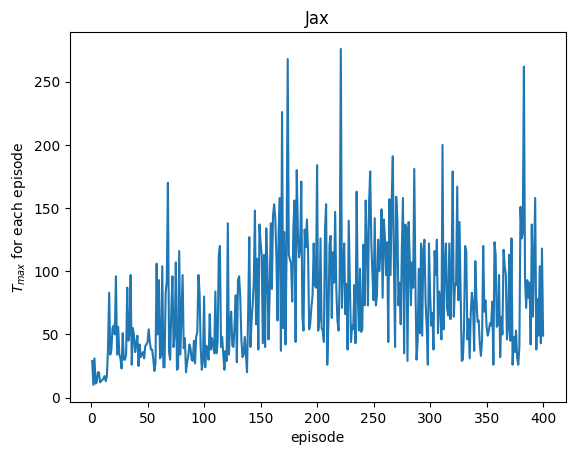

In [25]:
plt.plot(range(1, len(T_episode_maxes) +1), T_episode_maxes)
plt.ylabel(r"$T_{max}$ for each episode")
plt.xlabel('episode')
plt.title('Jax');

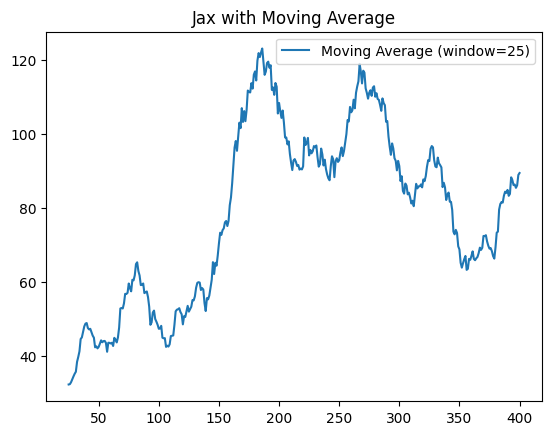

In [43]:
# Moving average of T_episode_maxes
window_size = 25
T_episode_maxes_ma = np.convolve(T_episode_maxes, np.ones(window_size)/window_size, mode='valid')
plt.plot(range(window_size, len(T_episode_maxes) +1), T_episode_maxes_ma, label=f'Moving Average (window={window_size})')
plt.legend()
plt.title('Jax with Moving Average');

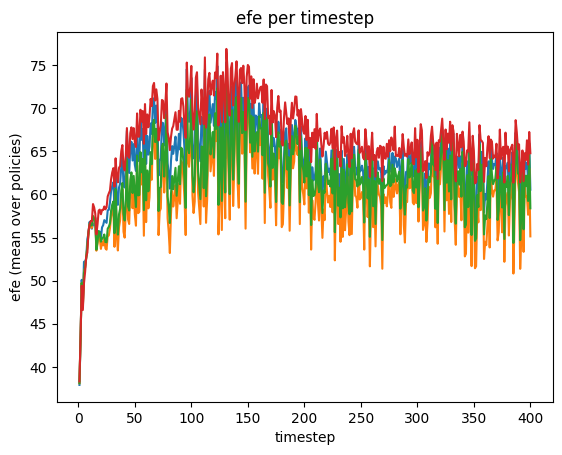

In [26]:
plt.plot(range(1, len(efe_means) +1), efe_means)
plt.ylabel(r"efe (mean over policies)")
plt.xlabel('timestep')
plt.title('efe per timestep');


In [27]:
# VFE not computed in rollout (infer_states does not return VFE)


In [28]:
# VFE not computed in rollout (infer_states does not return VFE)


modality = 0


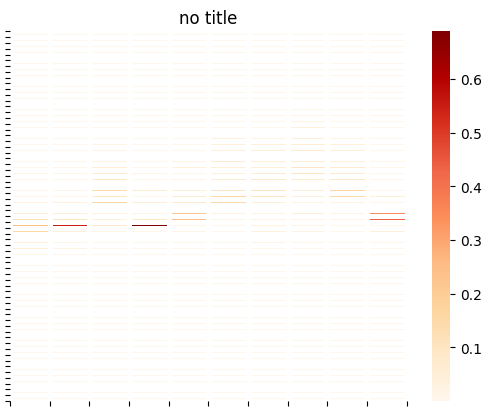

modality = 1


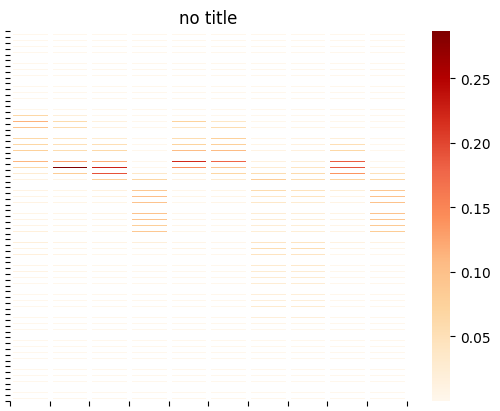

modality = 2


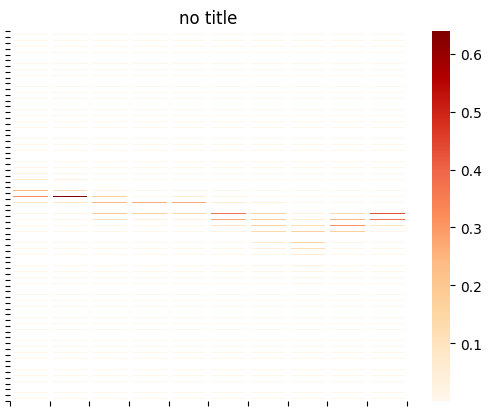

modality = 3


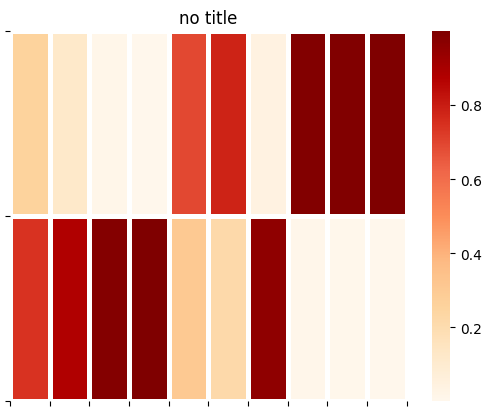

In [29]:
batch_num = 0
for m in range(len(agents.A)):
    print(f'modality = {m}')
    utils.plot_likelihood(agents.A[m][batch_num,:,:], title = 'no title')

factor = 0
actions = 0


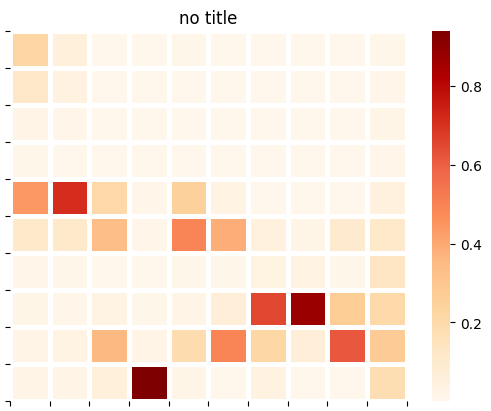

factor = 0
actions = 1


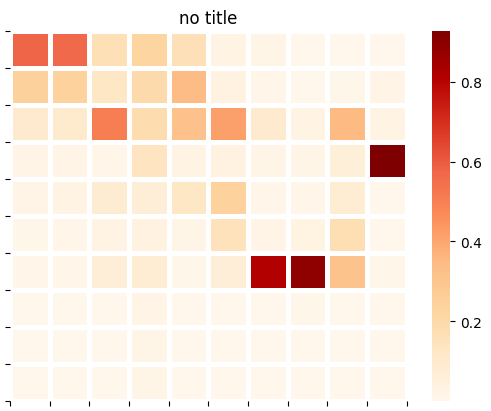

In [30]:
batch_num = 0
for f in range(len(agents.B)):
    for a in range(num_controls[f]):
        print(f'factor = {f}')
        print(f'actions = {a}')
        utils.plot_likelihood(agents.B[f][batch_num,:,:,a], title = 'no title')

In [31]:
# outcomes, actions, and infer_args are already set from rollout above


In [32]:
from pymdp import maths

In [33]:
len(outcomes[0][0])

49

In [34]:
len(infer_args[1][0][0])

49

In [35]:
len(actions[0])

49

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def plot_obs_vs_pred(qo_list, outcomes_list, onehot_obs, T_range=None, modality=0):
    """
    qo_list: list of inferred values at each time [T][observation dimension]
    outcomes_list: list of actual observations at each time [T][observation dimension] or indices
    onehot_obs: one-hot flag
    T_range: tuple of (T_start, T_end). If None, use all timesteps
    modality: modality index to visualize
    """
    # --- apply time range ---
    if T_range is not None:
        t_start, t_end = T_range
        qo_list       = qo_list[t_start:t_end]
        outcomes_list = outcomes_list[t_start:t_end]

    # --- matrixize inferred values (obs_dim × T) ---
    qo_arr = np.stack([np.array(qo[modality]) for qo in qo_list], axis=1)

    # --- get indices of actual observations ---
    obs_indices = []
    for out in outcomes_list:
        if onehot_obs:
            idx = int(np.argmax(out[modality]))
        else:
            idx = int(out[modality])
        obs_indices.append(idx)

    # --- plot ---
    T = qo_arr.shape[1]
    t = np.arange(T)

    fig, ax = plt.subplots(figsize=(12, 4))
    # use 'gray_r' so high probability is black and low probability is white
    im = ax.imshow(
        qo_arr,
        aspect='auto',
        cmap='gray_r',  # set this to 'gray_r'
        vmin=0, vmax=1,
        origin='lower'   # place index 0 at the bottom
    )
    fig.colorbar(im, ax=ax, label='Predicted Probability')

    # overlay actual observations with blue points
    ax.scatter(
        t, obs_indices,
        c='blue', s=10,
        label='Actual Observations'
    )

    ax.set_xlabel('Time')
    ax.set_ylabel('Observation Index')
    ax.set_title('Predicted Values (High=Black, Low=White) and Actual Observations (Blue Dots)')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

modality = 0


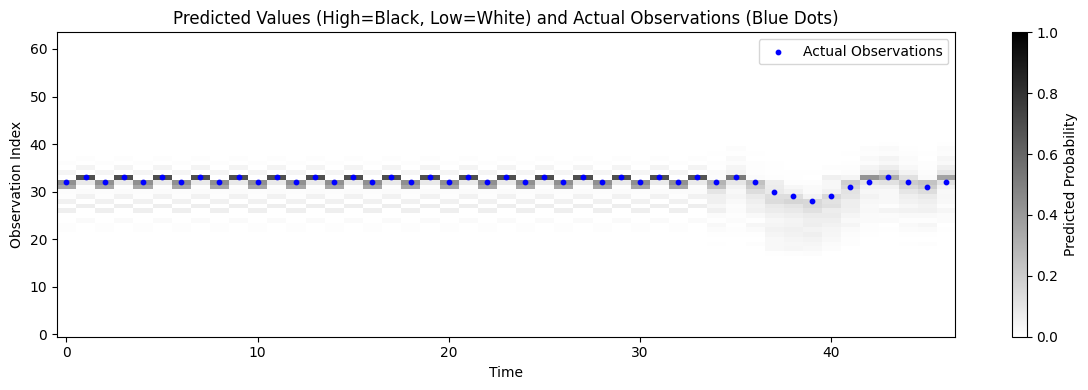

modality = 1


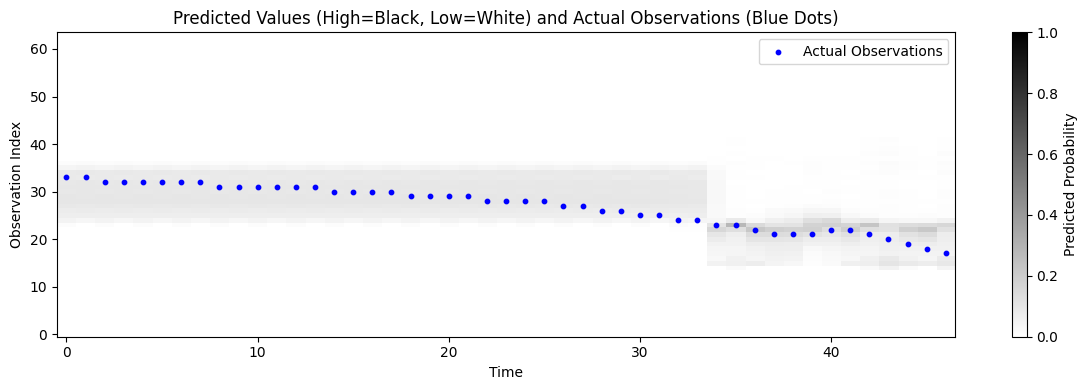

modality = 2


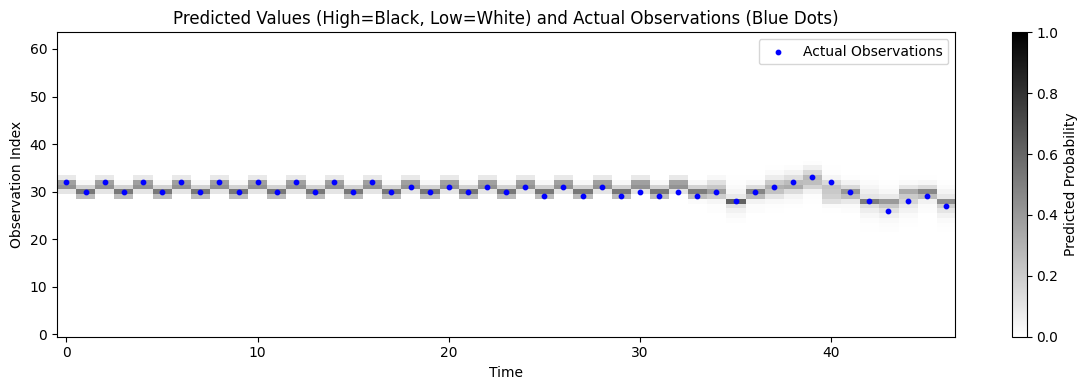

modality = 3


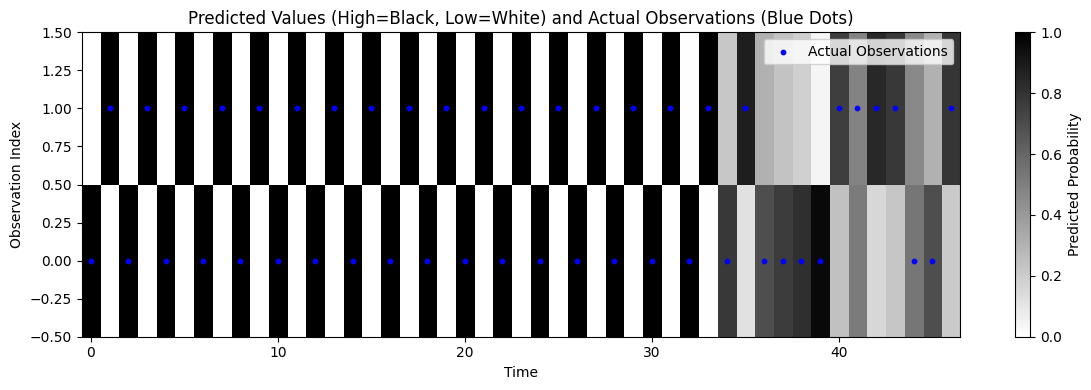

In [37]:
from pymdp.control import compute_expected_obs

qo_list = []
outcomes_list = []

T_start = 1 # >0
T_end = len(outcomes[0][0])

T_start = max(T_start, 1) # >0
# T_end = min(T_end, inference_horizon) # < inference_horizon

for T_inference in range(T_start, T_end):

    beliefs_T_inferece = jtu.tree_map( lambda x: x[:, T_inference], infer_args[1])

    # print(f"beliefs_T_inferece shape: {[b.shape for b in beliefs_T_inferece]}")
    # print(f"agents.A shape: {[a.shape for a in agents.A]}")

    batch_num = 0
    beliefs_T_inferece_selected_batch = jtu.tree_map(lambda x: jnp.take(x, batch_num, axis=0), beliefs_T_inferece)
    A_selected_batch = jtu.tree_map(lambda x: jnp.take(x, batch_num, axis=0), agents.A)
    qo = compute_expected_obs(beliefs_T_inferece_selected_batch, A_selected_batch, agents.A_dependencies)

    qo_list.append(qo)
    outcomes_list.append([outcomes[m][batch_num][T_inference] for m in range(len(qo))])

for m in range(len(qo)):
    print(f'modality = {m}')
    plot_obs_vs_pred(qo_list, outcomes_list, onehot_obs, (T_start, T_end), modality=m)

In [38]:
T_start = 1 # >0
T_end = 5 # < inference_horizon

T_start = max(T_start, 1) # >0
T_end = min(T_end, inference_horizon-1) # < inference_horizon

T_inference = 1
    factor = 0


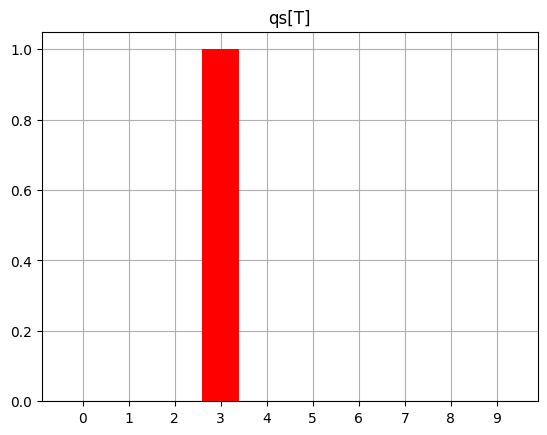

T_inference = 1
    modality = 0
    outcomes[0] = 33
    A[0]s = 32.2


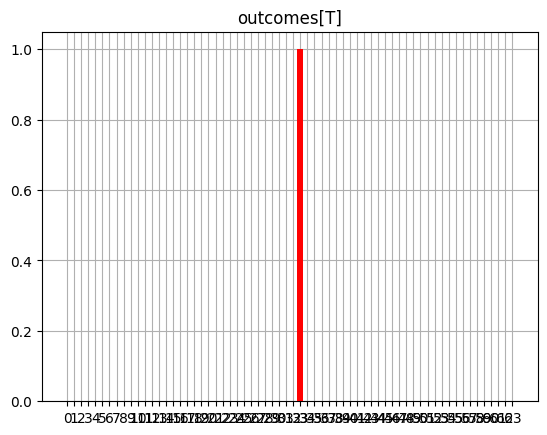

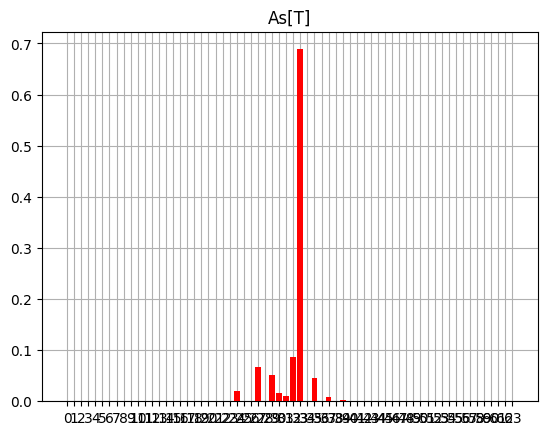

T_inference = 1
    modality = 1
    outcomes[1] = 33
    A[1]s = 29.8


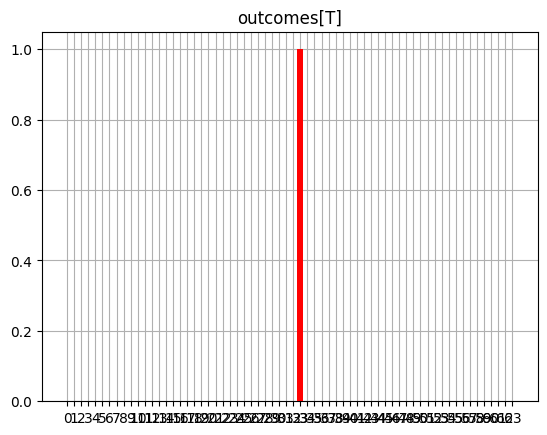

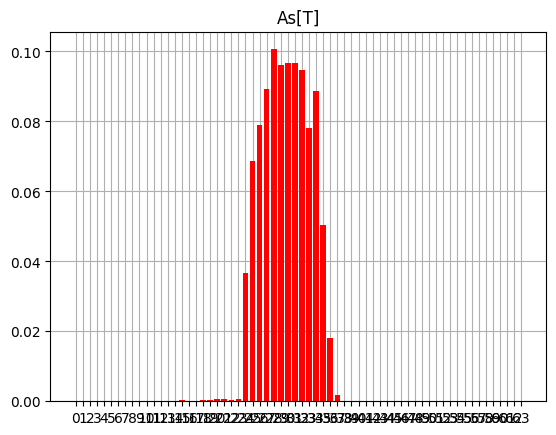

T_inference = 1
    modality = 2
    outcomes[2] = 30
    A[2]s = 30.0


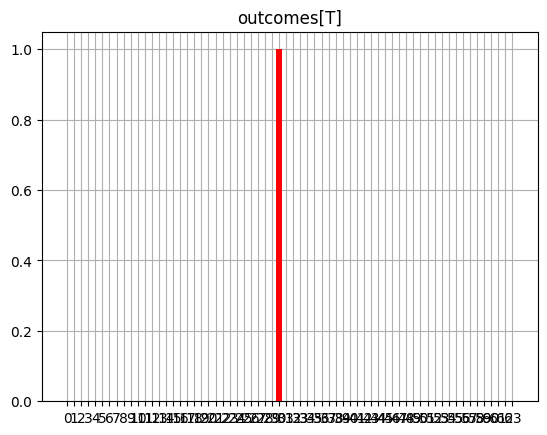

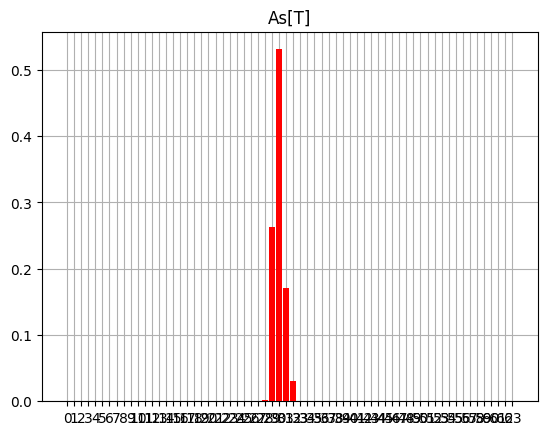

T_inference = 1
    modality = 3
    outcomes[3] = 1
    A[3]s = 1.0


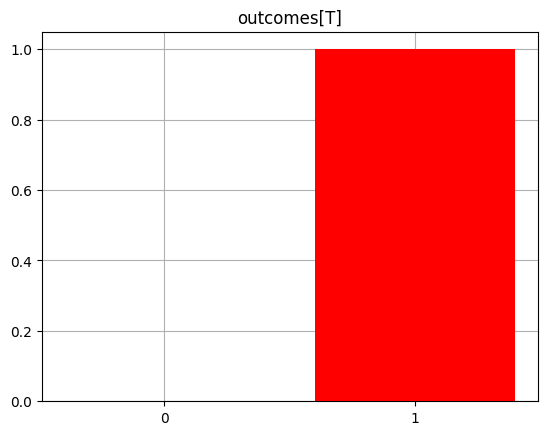

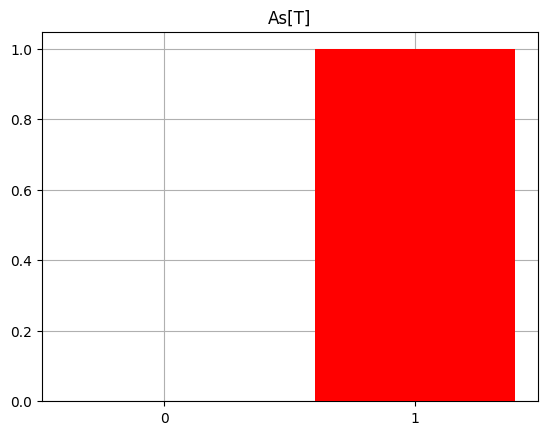

T_inference = 2
    factor = 0


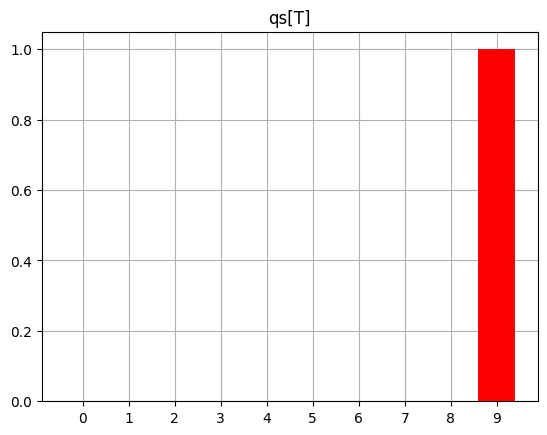

T_inference = 2
    modality = 0
    outcomes[0] = 32
    A[0]s = 30.9


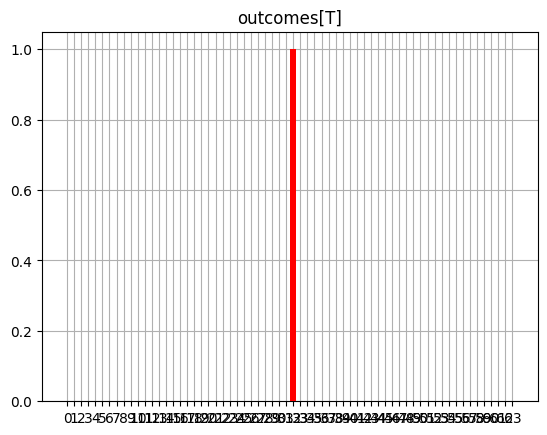

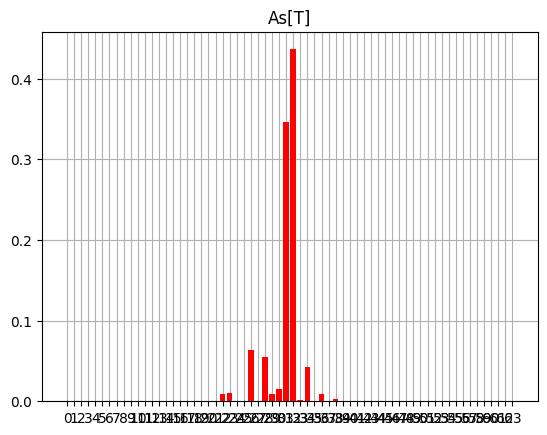

T_inference = 2
    modality = 1
    outcomes[1] = 33
    A[1]s = 29.6


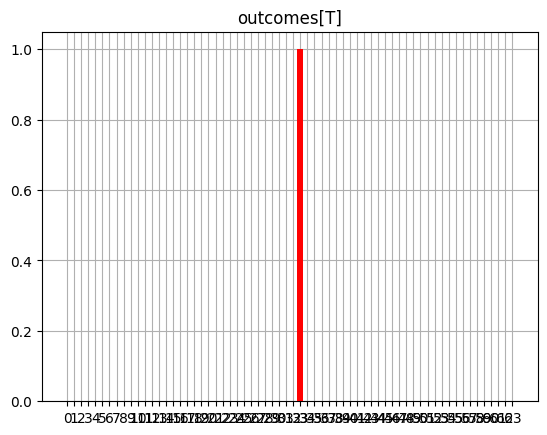

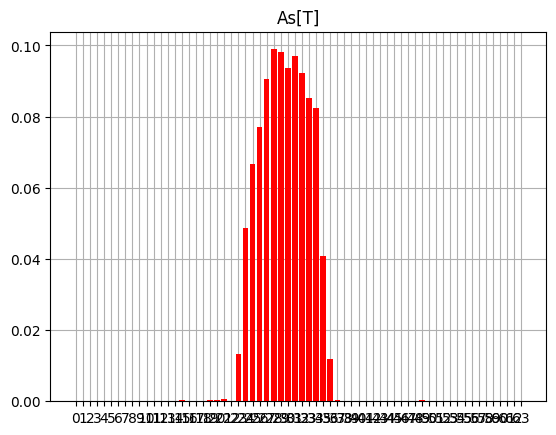

T_inference = 2
    modality = 2
    outcomes[2] = 32
    A[2]s = 31.5


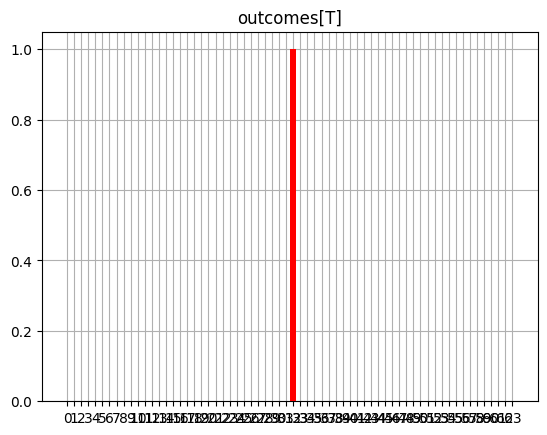

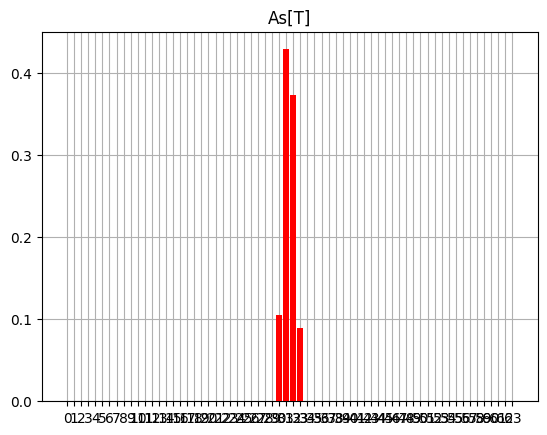

T_inference = 2
    modality = 3
    outcomes[3] = 0
    A[3]s = 0.0


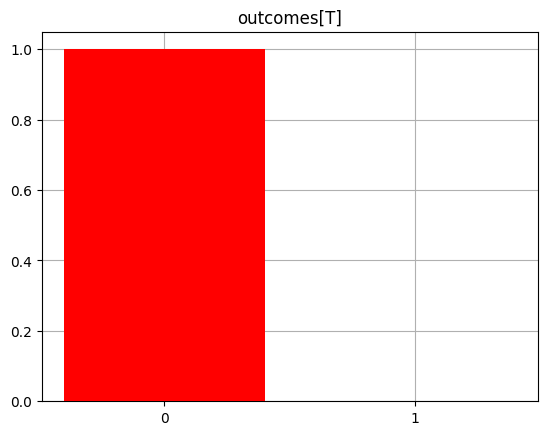

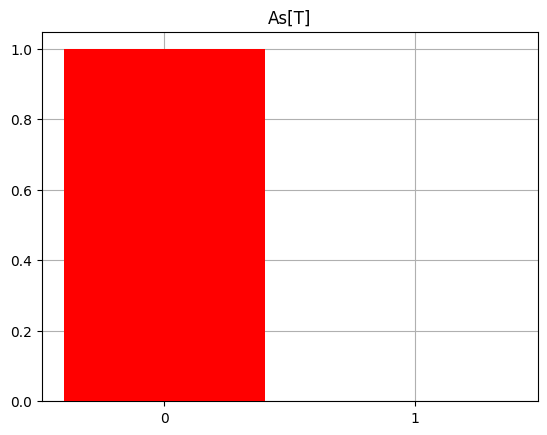

T_inference = 3
    factor = 0


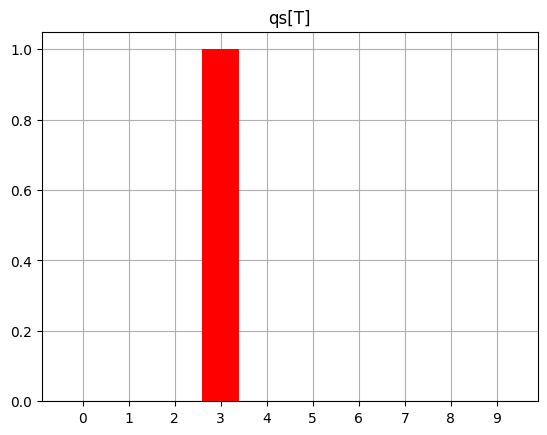

T_inference = 3
    modality = 0
    outcomes[0] = 33
    A[0]s = 32.2


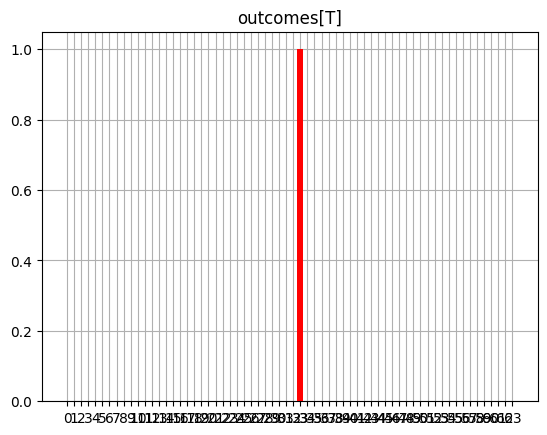

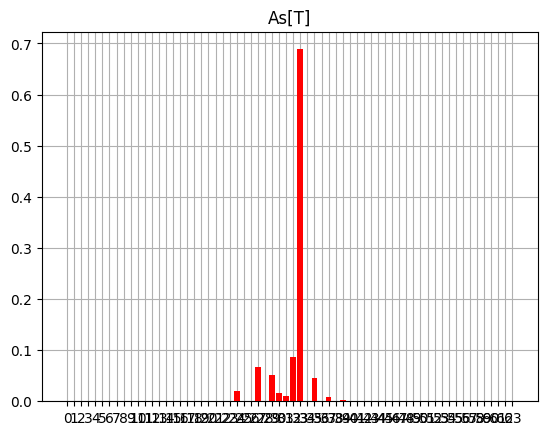

T_inference = 3
    modality = 1
    outcomes[1] = 33
    A[1]s = 29.8


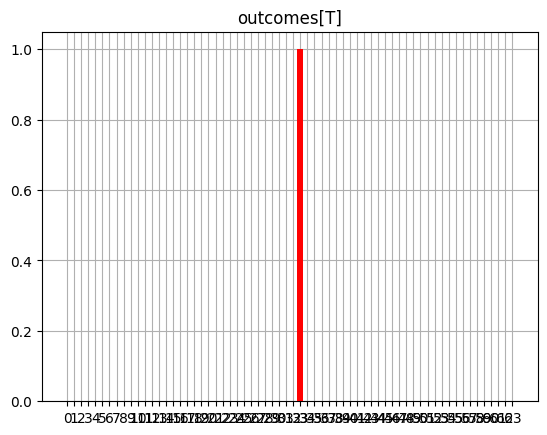

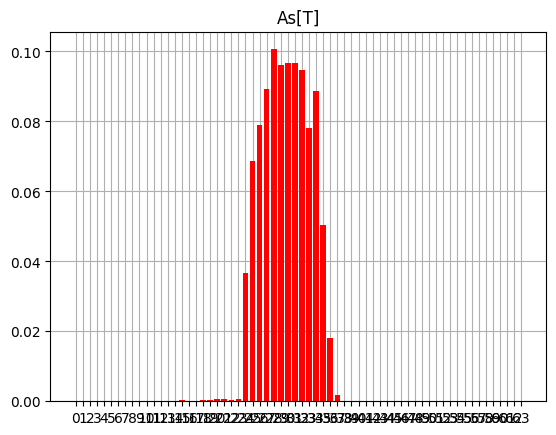

T_inference = 3
    modality = 2
    outcomes[2] = 30
    A[2]s = 30.0


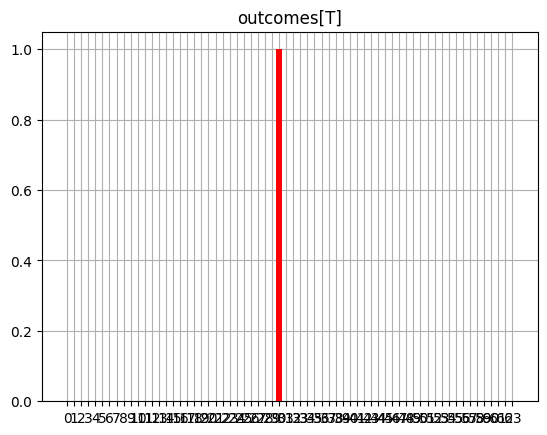

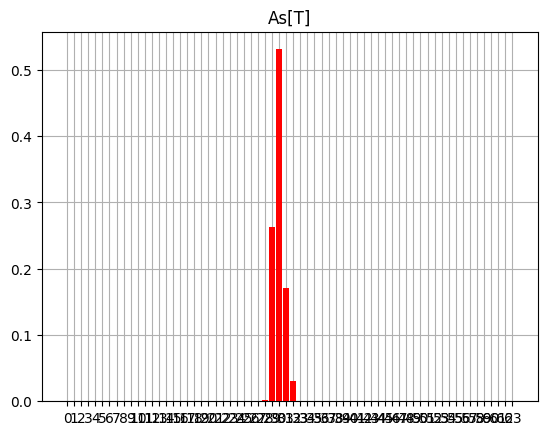

T_inference = 3
    modality = 3
    outcomes[3] = 1
    A[3]s = 1.0


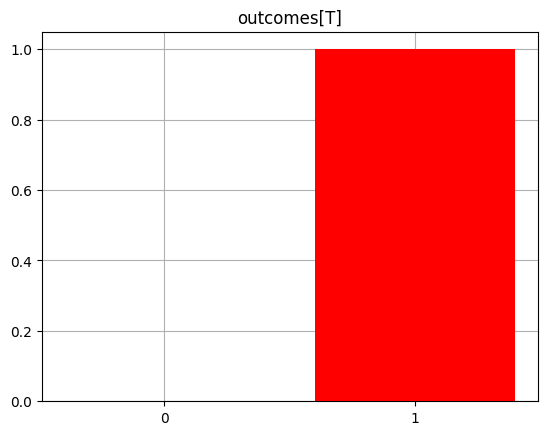

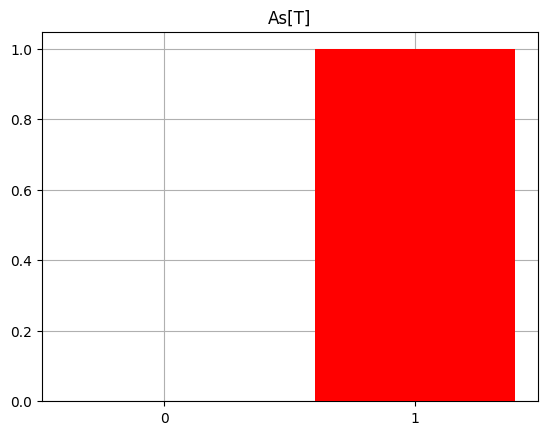

T_inference = 4
    factor = 0


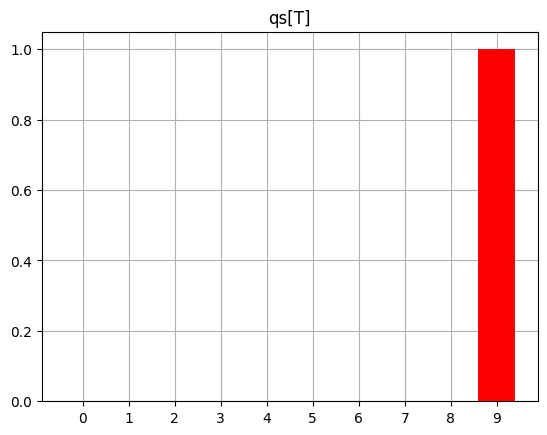

T_inference = 4
    modality = 0
    outcomes[0] = 32
    A[0]s = 30.9


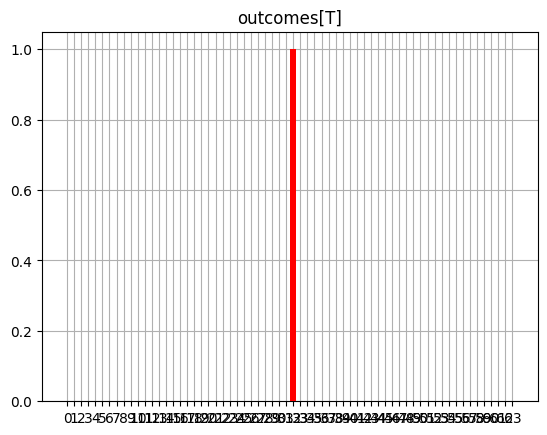

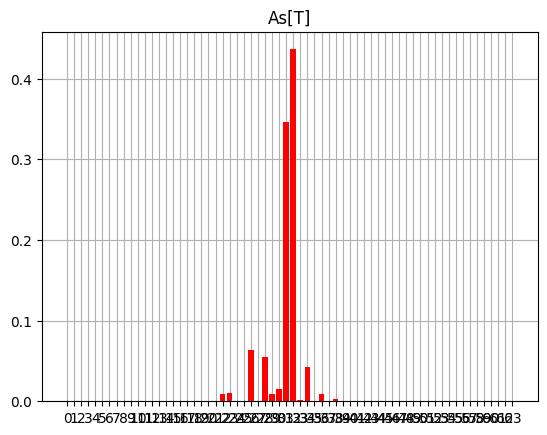

T_inference = 4
    modality = 1
    outcomes[1] = 32
    A[1]s = 29.6


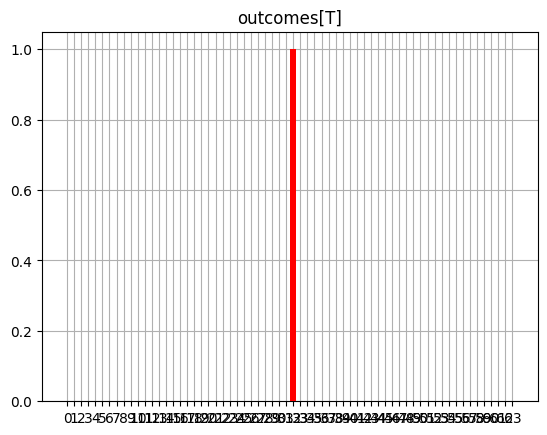

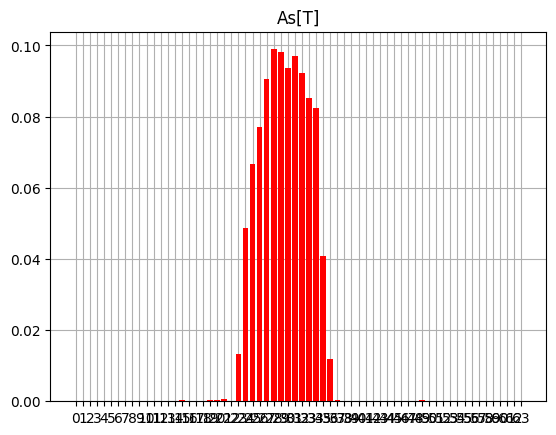

T_inference = 4
    modality = 2
    outcomes[2] = 32
    A[2]s = 31.5


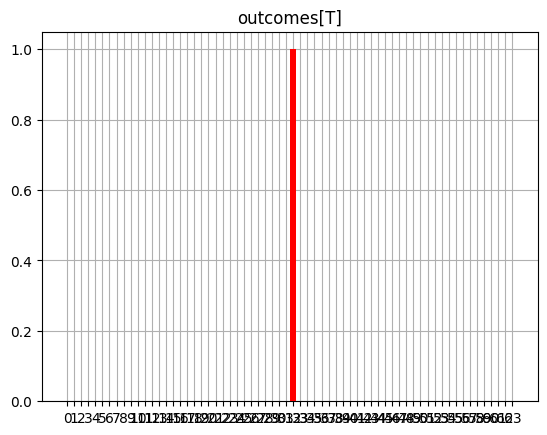

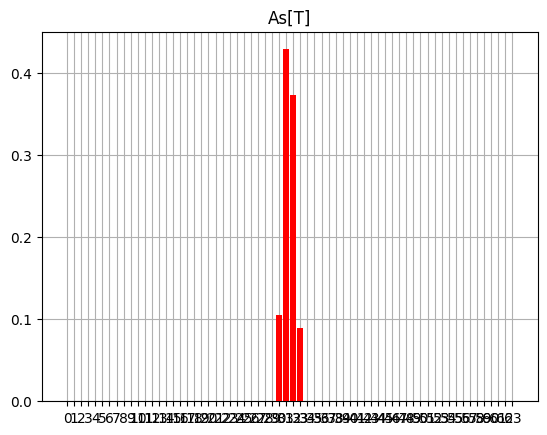

T_inference = 4
    modality = 3
    outcomes[3] = 0
    A[3]s = 0.0


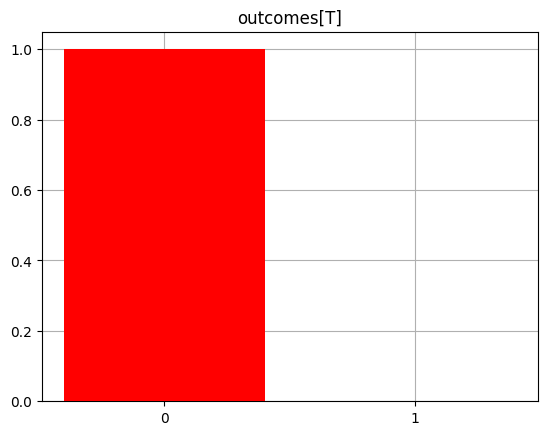

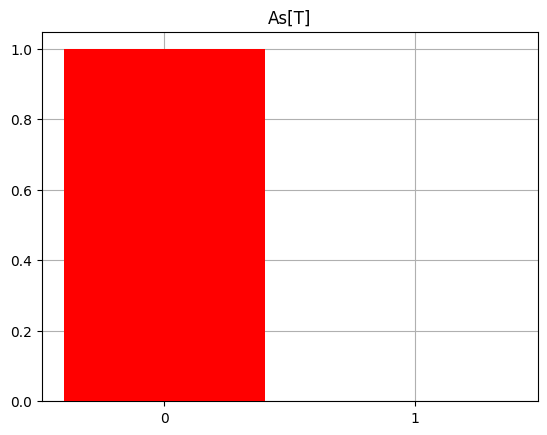

In [39]:
from pymdp.control import compute_expected_obs

for T_inference in range(T_start, T_end):

    beliefs_T_inferece = jtu.tree_map( lambda x: x[:, T_inference], infer_args[1])

    # print(f"beliefs_T_inferece shape: {[b.shape for b in beliefs_T_inferece]}")
    # print(f"agents.A shape: {[a.shape for a in agents.A]}")

    batch_num = 0
    beliefs_T_inferece_selected_batch = jtu.tree_map(lambda x: jnp.take(x, batch_num, axis=0), beliefs_T_inferece)
    A_selected_batch = jtu.tree_map(lambda x: jnp.take(x, batch_num, axis=0), agents.A)
    qo = compute_expected_obs(beliefs_T_inferece_selected_batch, A_selected_batch, agents.A_dependencies)

    for f in range(len(beliefs_T_inferece_selected_batch)):
        print(f'T_inference = {T_inference}')
        print(f'    factor = {f}')
        utils.plot_beliefs(beliefs_T_inferece_selected_batch[f], title = "qs[T]")

    for m in range(len(qo)):
        print(f'T_inference = {T_inference}')
        print(f'    modality = {m}')
        if onehot_obs == False:
            print(f"    outcomes[{m}] = {outcomes[m][batch_num][T_inference]}")
            print(f"    A[{m}]s = {jnp.dot(np.arange(len(qo[m])), qo[m]):.1f}")
            utils.plot_beliefs(qo[m], title = "As[T]")
        else:
            print(f"    outcomes[{m}] = {jnp.argmax(outcomes[m][batch_num][T_inference])}") # show the index where the one-hot vector equals 1
            print(f"    A[{m}]s = {jnp.dot(np.arange(len(qo[m])), qo[m]):.1f}")
            utils.plot_beliefs(outcomes[m][batch_num][T_inference], title = "outcomes[T]")
            utils.plot_beliefs(qo[m], title = "As[T]")

T_inference = 1
    action_prev = [[1]]


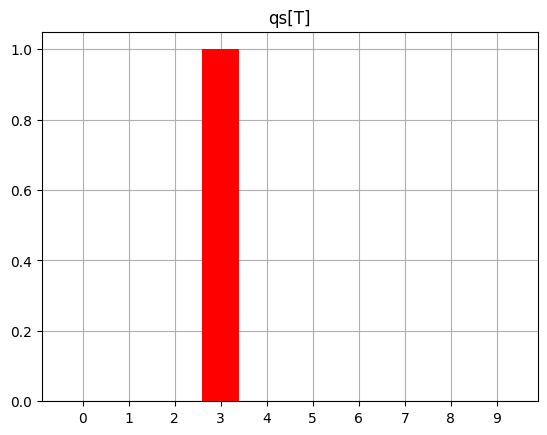

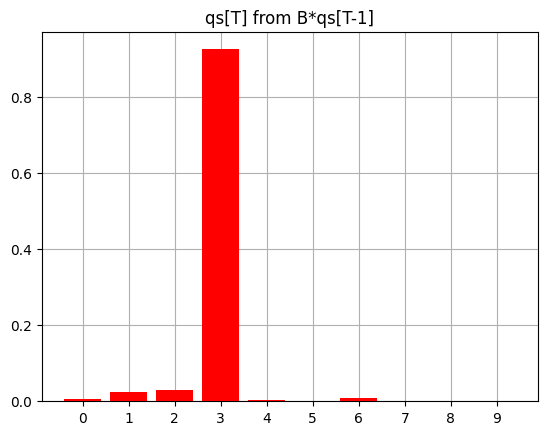

T_inference = 2
    action_prev = [[0]]


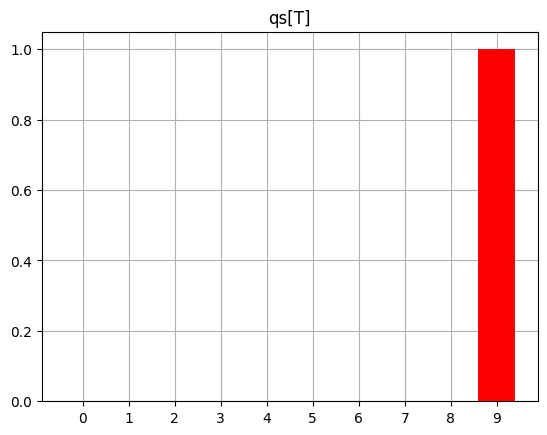

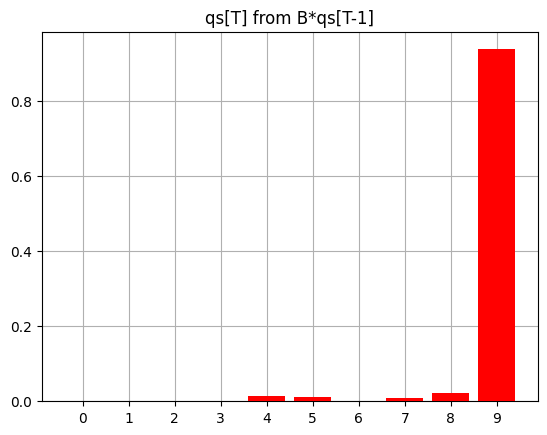

T_inference = 3
    action_prev = [[1]]


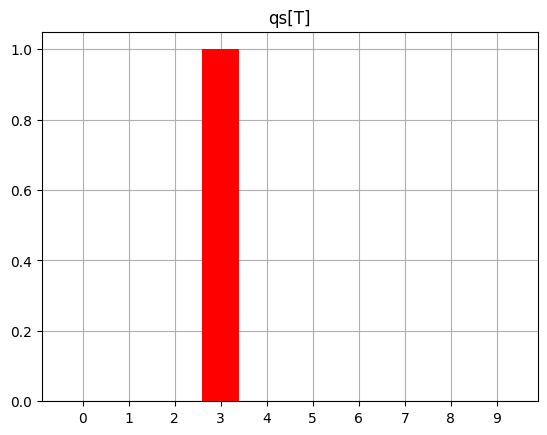

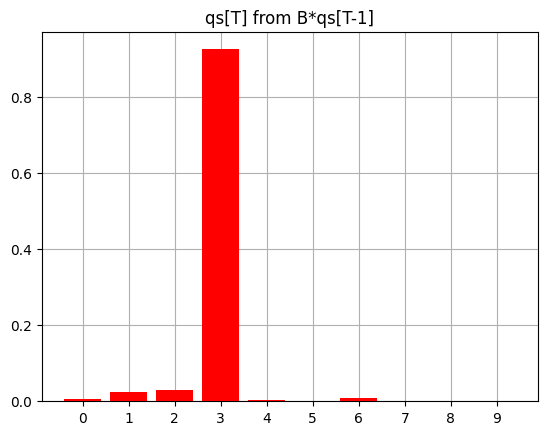

T_inference = 4
    action_prev = [[0]]


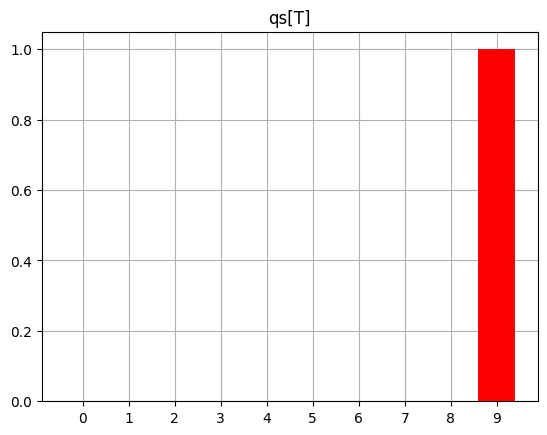

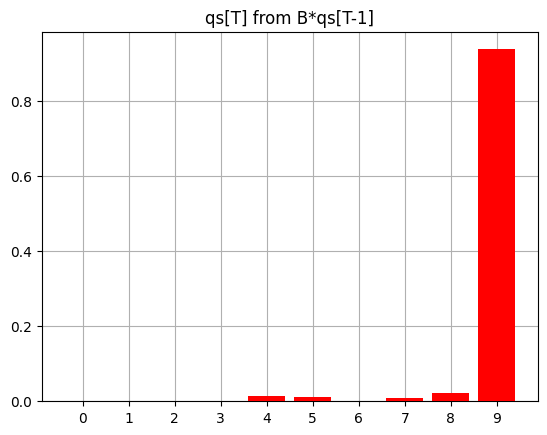

In [40]:
# Check whether the B tensor is learned correctly

from pymdp.control import compute_expected_state
from jax import vmap

for T_inference in range(T_start, T_end):

    print(f'T_inference = {T_inference}')

    batch_num = 0

    qs_0_T = infer_args[1][0][batch_num][T_inference]

    action_prev = actions[:,T_inference-1]
    print(f'    action_prev = {action_prev}')

    qs_prev = jtu.tree_map( lambda x: x[:, T_inference-1], infer_args[1])
    propagate_beliefs = partial(compute_expected_state, B_dependencies=agents.B_dependencies)
    pred = vmap(propagate_beliefs)(qs_prev, agents.B, action_prev)

    utils.plot_beliefs(qs_0_T, title = "qs[T]")
    utils.plot_beliefs(pred[0][batch_num], title = "qs[T] from B*qs[T-1]")

In [41]:
# D-learning is not implemented in rollout; skip this check
